In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/model_ready.csv')

X = df.drop(columns=['ID', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_model = joblib.load('../data/processed/best_model.pkl')

### Global feature importance (built-in, quick sanity check)

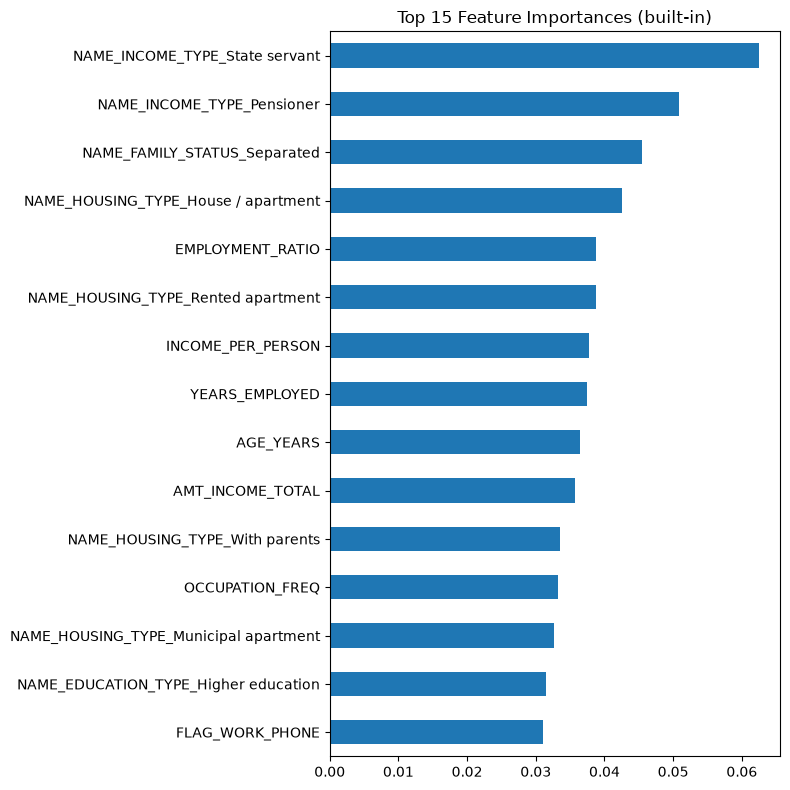

In [3]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (built-in)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### SHAP values - global explanation

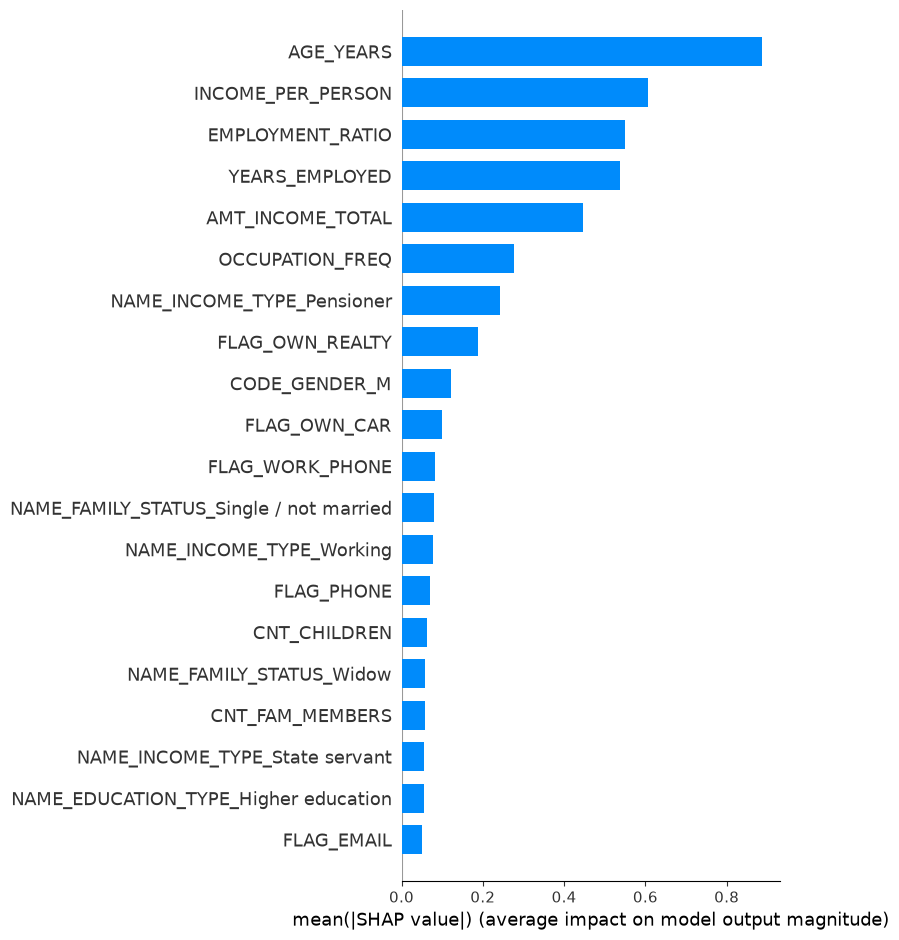

In [4]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For binary XGBoost, shap_values is usually a single array already for class 1
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

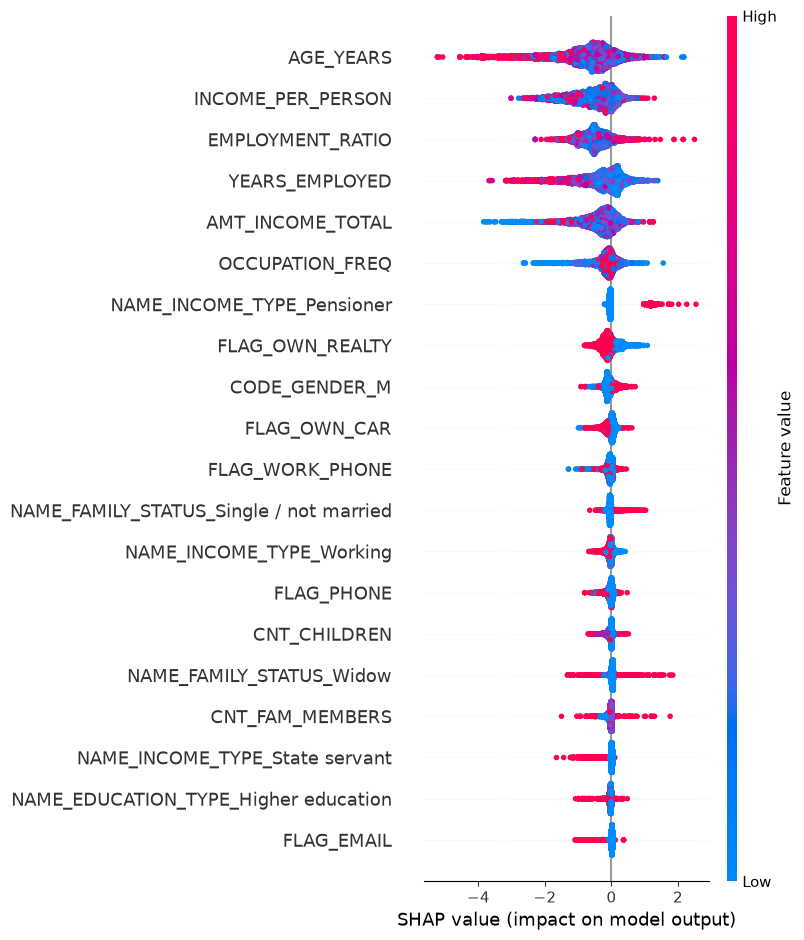

In [5]:
shap.summary_plot(shap_values, X_test, show=True)

### Explain individual predictions

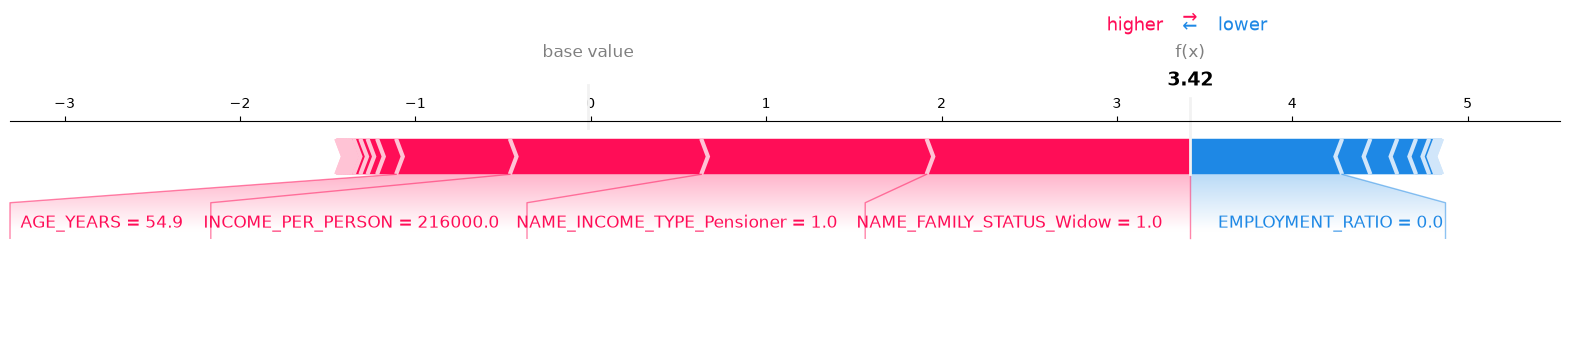

In [6]:
# Find indices of true positives and false negatives
y_pred = best_model.predict(X_test)
y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

true_positive_idx = np.where((y_test_reset == 1) & (y_pred == 1))[0][0]
false_negative_idx = np.where((y_test_reset == 1) & (y_pred == 0))[0][0]

# Force plot for a correctly caught bad applicant
shap.force_plot(
    explainer.expected_value, shap_values[true_positive_idx],
    X_test_reset.iloc[true_positive_idx], matplotlib=True, show=True
)

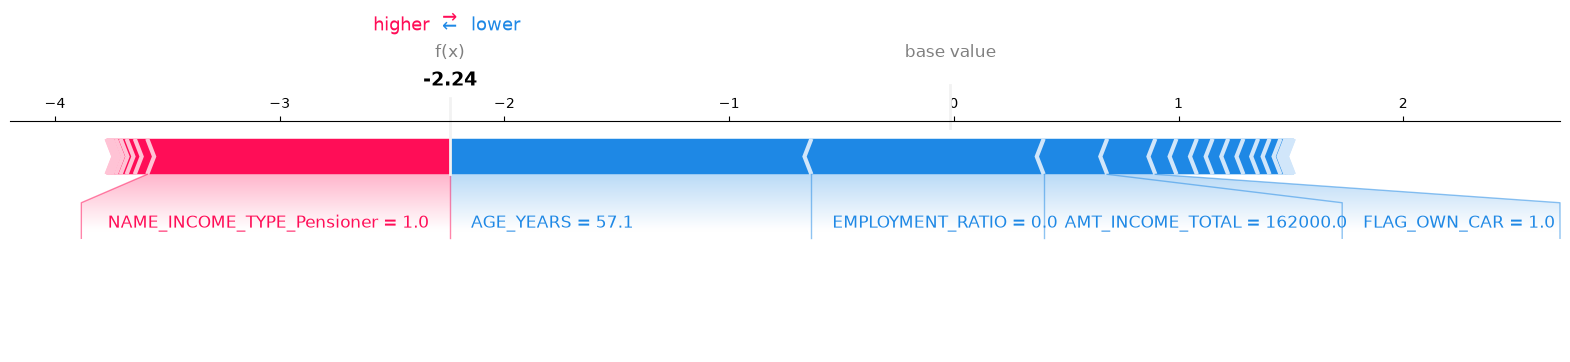

In [7]:
# Force plot for a missed bad applicant (false negative) — most interesting case
shap.force_plot(
    explainer.expected_value, shap_values[false_negative_idx],
    X_test_reset.iloc[false_negative_idx], matplotlib=True, show=True
)

Comparing a correctly identified risky applicant against a missed one reveals what the model is actually keying on. In both cases, being a pensioner nudged the prediction toward "risky" — but in the true positive case, this signal was reinforced by high per-person income and widowed status, while in the false negative case, it was outweighed by a car ownership flag, moderate income, and a zero employment ratio that the model treats as a stability marker rather than a risk factor. This suggests the model has learned a fairly reasonable heuristic — "older, non-working, but with assets/income = safe" — that happens to break down for individual pensioners who are risky despite looking financially stable on paper. This kind of error is arguably more forgivable than a random miss, since it's a genuinely plausible pattern the model is following, just one that doesn't always hold.

### Error Analysis

In [8]:
errors_df = X_test_reset.copy()
errors_df['true_label'] = y_test_reset.values
errors_df['predicted_label'] = y_pred
errors_df['error_type'] = 'correct'
errors_df.loc[(errors_df['true_label'] == 1) & (errors_df['predicted_label'] == 0), 'error_type'] = 'false_negative'
errors_df.loc[(errors_df['true_label'] == 0) & (errors_df['predicted_label'] == 1), 'error_type'] = 'false_positive'

# Compare feature averages across error types
errors_df.groupby('error_type')[['AMT_INCOME_TOTAL', 'AGE_YEARS', 'YEARS_EMPLOYED']].mean()

,AMT_INCOME_TOTAL,AGE_YEARS,YEARS_EMPLOYED
error_type,,,
correct,186172.708990,43.847839,6.110449
false_negative,167683.846154,45.750769,6.735385
false_positive,188181.818182,45.273701,4.135714
